# 신경망 없이 MNIST 숫자 분류
출처: https://www.kaggle.com/code/dhconnelly/mnist-without-neural-nets

# 전체 그림

- 이것은 28x28 픽셀 배열(훈련 및 테스트 세트에서 "pixel0"부터 "pixel783"까지 저장됨)을 기반으로 클래스 0부터 9까지를 예측하려는 다중 클래스 분류 문제입니다. 각 픽셀은 0에서 255 사이의 값을 가집니다. [지침](https://www.kaggle.com/competitions/digit-recognizer)에 따라 평가 지표는 정확도이므로 이를 사용할 것입니다.
- 신경망 기반 솔루션을 피하고 대신 [확률적 경사 하강법](https://scikit-learn.org/stable/modules/sgd.html), [k-최근접 이웃](https://scikit-learn.org/stable/modules/neighbors.html#classification), [그래디언트 부스팅 트리](https://xgboost.readthedocs.io/en/stable/tutorials/model.html)를 훈련하고 비교합니다.
- 테스트 세트에서 97% 분류 정확도를 목표로 합니다.

In [1]:
import multiprocessing
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import model_selection, linear_model, metrics, neighbors
import xgboost as xgb

# 데이터 가져오기 및 구조 이해

In [ ]:
def load_data(path):
    # .npz 파일 로드
    mnist_train = np.load(path)
    
    # 저장된 키를 사용하여 배열 액세스
    X_train_images = mnist_train['train_images']
    y_train_labels = mnist_train['train_labels']
    
    # 이미지를 28x28에서 784로 평탄화
    train_images_flat = X_train_images.reshape(X_train_images.shape[0], -1)
    
    # 레이블을 첫 번째 열로, 그 다음 픽셀 열로 DataFrame 생성
    data = pd.DataFrame(train_images_flat)
    data.insert(0, 'label', y_train_labels)
    data.index += 1
    
    return data

data = load_data("../assets/mnist_train.npz")

In [3]:
data.shape

(60000, 785)

In [4]:
data.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data.describe()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [ ]:
# null 데이터 없음
assert pd.isnull(data).any().sum() == 0

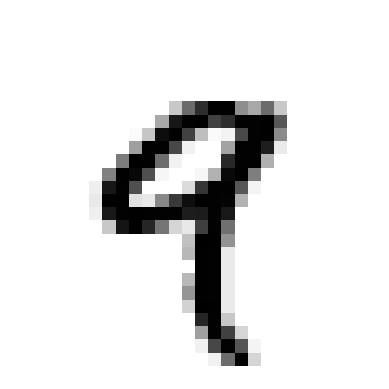

In [7]:
# 행은 그레이스케일 비트맵

def plot_digit(row):
    image = row[1:].to_numpy().reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

plot_digit(data[data["label"] == 9].iloc[0])

In [ ]:
# 유효한 비트만, 0-9 레이블만
assert list(np.unique(data.values)) == list(range(256))
assert list(np.unique(data["label"].values)) == list(range(10))

# 테스트 세트 생성

In [9]:
test_size = 0.2
train, test = model_selection.train_test_split(data, test_size=test_size, random_state=19)

def split_Xy(data):
    return data.iloc[:, 1:], data.iloc[:, 0]

X_train, y_train = split_Xy(train)
X_test, y_test = split_Xy(test)

# 데이터 탐색 및 통찰 발견

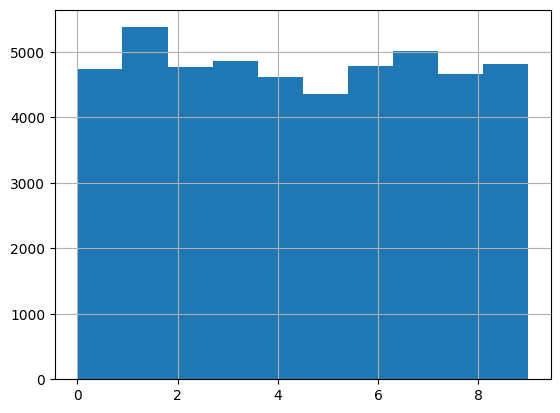

In [ ]:
# 레이블이 균형을 이루고 있나요?
y_train.hist()
plt.show()
# 꽤 균형이 잡혀 있습니다!

# 모델 선택 및 훈련

In [ ]:
clfs = {
    "sgd": linear_model.SGDClassifier(random_state=19, n_jobs=2),
    "xgb": xgb.XGBClassifier(random_state=19, tree_method="hist", device="cuda"), #xgb.XGBClassifier(random_state=19, tree_method="hist"),  # "gpu_hist"에서 "hist"로 변경
    "knn": neighbors.KNeighborsClassifier(n_jobs=2),
}

In [ ]:
# 모델 전반에 걸쳐 교차 검증 및 훈련 정확도 점수 계산

def crossval(clf):
    return model_selection.cross_val_score(
        clf, X_train, y_train, cv=3, scoring="accuracy", verbose=2, n_jobs=2)

def crossval_all(clfs):
    cv_scores = {}
    for name, clf in clfs.items():
        print(f"{name} 평가 중...")
        begin = time.perf_counter()
        cv_scores[name] = crossval(clf)
        end = time.perf_counter()
        print(f"{name} 평가 완료 ({end-begin:.2f}초)")
    return cv_scores

def score(clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_train)
    return metrics.accuracy_score(y_train, y_pred)

def score_all(clfs):
    train_scores = {}
    for name, clf in clfs.items():
        print(f"{name} 피팅 중...")
        begin = time.perf_counter()
        train_scores[name] = score(clf)
        end = time.perf_counter()
        print(f"{name} 피팅 완료 ({end-begin:.2f}초)")
    return train_scores

def evaluate_all(clfs):
    train_scores = score_all(clfs)
    cv_scores = crossval_all(clfs)
    print(f"모델\t훈련\t교차검증")
    for name in clfs:
        train_acc, cv_acc = train_scores[name], cv_scores[name].mean()
        print(f"{name}\t{train_acc:0.2f}\t{cv_acc:0.2f}")

In [13]:
evaluate_all(clfs)

fitting sgd...
fit sgd in 36.64 seconds
fitting xgb...
fit sgd in 36.64 seconds
fitting xgb...


c:\Users\lota\Documents\SourceCodes\ML_25_2\.venv\Lib\site-packages\xgboost\core.py:774: UserWarning: [17:16:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


fit xgb in 12.85 seconds
fitting knn...
fit knn in 46.96 seconds
evaluating sgd...
fit knn in 46.96 seconds
evaluating sgd...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   47.7s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   47.7s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


evaluated sgd in 47.93 seconds
evaluating xgb...


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   31.0s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


evaluated xgb in 31.24 seconds
evaluating knn...


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   24.6s finished


evaluated knn in 24.92 seconds
model	train	cv
sgd	0.90	0.88
xgb	1.00	0.97
knn	0.98	0.97


## 생각

xgboost는 잘 수행되고 있습니다 - 100% 훈련 정확도와 평균 교차 검증 정확도 약 96.9%로, 편향이 매우 낮습니다. 하지만 분산이 우리가 원하는 것보다 약간 높습니다. 테스트 세트에서 97% 정확도를 목표로 하기 때문입니다. 미세 조정에서 이를 개선할 수 있는지 봅시다.

knn도 잘 수행되고 있으며, 분산이 더 낮습니다. 이것도 미세 조정을 시도해 봅시다.

# 모델 미세 조정

In [ ]:
# knn의 k에 대해 미세 조정

knn_search = model_selection.GridSearchCV(
    clfs["knn"],
    param_grid={ "n_neighbors": [3, 4, 5, 6], "weights": ["uniform", "distance"] },
    scoring="accuracy",
    cv=3, n_jobs=2, verbose=2
)

knn_search.fit(X_train, y_train)
print(knn_search.best_params_)
print(knn_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'n_neighbors': 4, 'weights': 'distance'}
0.9702708333333333
{'n_neighbors': 4, 'weights': 'distance'}
0.9702708333333333


In [ ]:
# xgboost를 미세 조정하여 분산 감소

xgb_search = model_selection.GridSearchCV(
    clfs["xgb"],
    param_grid={ "gamma": [0.0, 0.01, 0.1, 1.0],  },
    scoring="accuracy",
    cv=3, n_jobs=2, verbose=2,
)

xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_)
print(xgb_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
{'gamma': 0.01}
0.9722083333333332
{'gamma': 0.01}
0.9722083333333332


In [ ]:
# 최고의 모델 선택
searches = [knn_search, xgb_search]
final_clf = max([(search.best_score_, search.best_estimator_) for search in searches])[1]
print(final_clf)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.01, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


# 테스트 정확도 추정

In [ ]:
final_clf.fit(X_train, y_train)
y_test_pred = final_clf.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, y_test_pred)
print(f"테스트 정확도: {test_accuracy:.4f}")
test_accuracy

Test Accuracy: 0.9741


0.9740833333333333

좋습니다! 97%를 넘었습니다!

# 훈련된 모델 저장

In [ ]:
import joblib

# 훈련된 모델 저장
model_path = '../assets/mnist_ml_model.pkl'
joblib.dump(final_clf, model_path)

print("=" * 60)
print("✓ 모델 저장 완료!")
print("=" * 60)
print(f"모델 경로: {model_path}")
print(f"모델 타입: {type(final_clf).__name__}")
print(f"테스트 정확도: {test_accuracy:.4f}")
print("=" * 60)

✓ Model saved successfully!
Model path: ../assets/mnist_ml_model.pkl
Model type: XGBClassifier
Test accuracy: 0.9741


# 예측 생성

In [ ]:
"""# test.csv를 로드하고 예측 수행 (평가를 위한 레이블 없음)
test_data = pd.read_csv("test.csv")
print(f"테스트 데이터 크기: {test_data.shape}")

# 예측 수행
y_pred = final_clf.predict(test_data)

# 예측을 CSV로 저장
submission = pd.DataFrame(y_pred, columns=["Label"])
submission.index += 1
submission.index.name = "ImageId"
submission.to_csv("submission.csv", index=True)

print(f"\n예측이 'submission.csv'에 저장되었습니다")
print(f"예측 개수: {len(y_pred)}")
print(f"\n예측된 레이블 분포:")
print(pd.Series(y_pred).value_counts().sort_index())"""

'# Load test.csv and make predictions (no labels available for evaluation)\ntest_data = pd.read_csv("test.csv")\nprint(f"Test data shape: {test_data.shape}")\n\n# Make predictions\ny_pred = final_clf.predict(test_data)\n\n# Save predictions to CSV\nsubmission = pd.DataFrame(y_pred, columns=["Label"])\nsubmission.index += 1\nsubmission.index.name = "ImageId"\nsubmission.to_csv("submission.csv", index=True)\n\nprint(f"\nPredictions saved to \'submission.csv\'")\nprint(f"Number of predictions: {len(y_pred)}")\nprint(f"\nPredicted label distribution:")\nprint(pd.Series(y_pred).value_counts().sort_index())'